# FINAL — GNN leggere con preprocessing integrato

Questo notebook è una versione **più leggera** della parte GNN.

Il notebook GNN completo era troppo pesante perché usava fino a 200 tracce per jet e costruiva il grafo dinamicamente durante il training. Qui mantengo la stessa idea fisica, ma riduco il costo:

```text
1. uso tutte le feature track/jet già scelte nel preprocessing;
2. tengo solo le top tracce per jet, ordinate per pt_log1p se disponibile;
3. confronto due modelli:
   - EdgeConv Autoencoder;
   - Attention/Transformer Graph Autoencoder;
4. training solo su QCD;
5. test su QCD vs Emerging Jets.
```

Se il preprocessing completo esiste già:

```text
FINAL/processed/repr2_sequences.npz
```

il notebook crea una versione leggera:

```text
FINAL/processed/repr2_gnn_light.npz
```

Se invece non esiste nessun preprocessing, c'è una sezione opzionale per ricostruire il dataset direttamente dagli HDF5 raw.

## 1. Import, seed e device

In [1]:
from pathlib import Path
import json
import copy
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Device:", device)

PyTorch: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Device: cuda


## 2. Configurazione

In [2]:
# -----------------------------------------------------------------------------
# Preprocessing leggero
# -----------------------------------------------------------------------------
MAX_TRACKS_GNN = 64
MAX_TRAIN = 25_000
MAX_EVAL = 20_000
MAX_SIG = 40_000

# Se repr2_gnn_light.npz esiste già, non lo ricreo.
# Se vuoi forzare la ricreazione da repr2_sequences.npz, metti True.
REBUILD_LIGHT_FROM_FULL = False

# Se non hai repr2_sequences.npz, puoi costruire direttamente da HDF5.
BUILD_FROM_RAW_H5_IF_NEEDED = False

# -----------------------------------------------------------------------------
# Modelli da eseguire
# -----------------------------------------------------------------------------
RUN_EDGECONV = True
RUN_ATTENTION_GNN = True

# -----------------------------------------------------------------------------
# Training
# -----------------------------------------------------------------------------
N_EPOCHS = 70
PATIENCE = 10
LR = 1e-3
WEIGHT_DECAY = 1e-5

BATCH_SIZE_EDGECONV = 128
BATCH_SIZE_ATTENTION = 192

# -----------------------------------------------------------------------------
# Modelli leggeri
# -----------------------------------------------------------------------------
EDGE_HIDDEN_DIM = 64
EDGE_LATENT_DIM = 16
EDGE_N_BLOCKS = 2
EDGE_K = 6

ATTN_EMBED_DIM = 64
ATTN_LATENT_DIM = 16
ATTN_N_LAYERS = 2
ATTN_N_HEADS = 4
ATTN_DROPOUT = 0.05

# La loss track resta dominante; la ricostruzione jet è un aiuto leggero.
TRACK_LOSS_WEIGHT = 1.0
JET_LOSS_WEIGHT = 0.20

DO_FEATURE_RECONSTRUCTION_ERRORS = True
DO_LATENT_LOGISTIC_DIAGNOSTIC = True

print("MAX_TRACKS_GNN:", MAX_TRACKS_GNN)
print("MAX_TRAIN:", MAX_TRAIN, "MAX_EVAL:", MAX_EVAL, "MAX_SIG:", MAX_SIG)

MAX_TRACKS_GNN: 64
MAX_TRAIN: 25000 MAX_EVAL: 20000 MAX_SIG: 40000


## 3. Path

In [3]:
CANDIDATE_BASES = [Path(".."), Path("."), Path("FINAL")]

PROJECT_BASE = None
for base in CANDIDATE_BASES:
    if (base / "processed").exists() or (base / "outputs").exists():
        PROJECT_BASE = base
        break

if PROJECT_BASE is None:
    PROJECT_BASE = Path("..")

PROCESSED_DIR = PROJECT_BASE / "processed"
OUTPUT_DIR = PROJECT_BASE / "outputs" / "gnn_light"
PLOTS_DIR = OUTPUT_DIR / "plots"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

FULL_SEQ_PATH = PROCESSED_DIR / "repr2_sequences.npz"
LIGHT_SEQ_PATH = PROCESSED_DIR / "repr2_gnn_light.npz"

print("PROJECT_BASE:", PROJECT_BASE.resolve())
print("FULL_SEQ_PATH:", FULL_SEQ_PATH.resolve())
print("LIGHT_SEQ_PATH:", LIGHT_SEQ_PATH.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

PROJECT_BASE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL
FULL_SEQ_PATH: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed\repr2_sequences.npz
LIGHT_SEQ_PATH: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed\repr2_gnn_light.npz
OUTPUT_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\gnn_light


## 4. Feature safe e controlli anti-leakage

In [4]:
DEFAULT_JET_FEATURES = [
    "pt", "eta", "mass", "energy",
    "Qw_clusterSoftDrop",
    "C2_clusterSoftDrop", "D2_clusterSoftDrop",
    "Tau1_clusterSoftDrop", "Tau2_clusterSoftDrop",
    "Tau3_clusterSoftDrop", "Tau4_clusterSoftDrop",
    "Tau21_clusterSoftDrop", "Tau32_clusterSoftDrop",
    "ECF1_clusterSoftDrop", "ECF2_clusterSoftDrop",
]

DEFAULT_TRACK_FEATURES = [
    "pt_log1p", "d0_log1p", "z0SinTheta",
    "deta", "dphi",
    "qOverP", "chiSquared", "radiusOfFirstHit",
    "IP3D_signed_d0_significance",
    "IP3D_signed_z0_significance",
    "numberOfPixelHits", "numberOfInnermostPixelLayerHits",
    "numberOfSCTHits", "numberOfSCTHoles",
    "numberOfPixelSharedHits", "numberOfSCTSharedHits",
]

FORBIDDEN_SUBSTRINGS = [
    "isDisplaced",
    "isTagged",
    "salt_pdisp",
    "displacedPtFraction",
    "flavour_label",
    "truthOriginLabel",
    "truthVertexIndex",
    "VSIVertexIndex",
    "truth_dark_pions",
    "truth_stable_non_geant",
    "eventNumber",
    "mcEventWeight",
    "averageInteractionsPerCrossing",
    "actualInteractionsPerCrossing",
    "nPrimaryVertices",
    "isRun3",
]

def check_leakage(feature_names):
    bad = []
    for name in feature_names:
        for forbidden in FORBIDDEN_SUBSTRINGS:
            if forbidden.lower() in name.lower():
                bad.append(name)
    if bad:
        raise RuntimeError("Feature potenzialmente leaky trovate: " + ", ".join(bad))
    print("Leakage check OK.")

## 5. Utility preprocessing

In [5]:
def first_existing_key(data, candidates, required=True):
    for key in candidates:
        if key in data:
            return key
    if required:
        raise KeyError(
            "Nessuna delle chiavi candidate è presente: "
            + ", ".join(candidates)
            + "\nChiavi disponibili: "
            + ", ".join(data.keys())
        )
    return None

def finite_array(X, name):
    X = np.asarray(X, dtype=np.float32)
    if not np.isfinite(X).all():
        print(f"[WARN] {name}: sostituisco NaN/inf con 0.")
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return X

def find_feature_index(names, candidates):
    lower = [n.lower() for n in names]
    for cand in candidates:
        cand_l = cand.lower()
        for i, name in enumerate(lower):
            if name == cand_l or cand_l in name:
                return i
    return None

def clean_tracks(X, M):
    X = finite_array(X, "tracks").copy()
    M = np.asarray(M).astype(bool)
    X[~M] = 0.0
    return X, M

def select_top_tracks(X, M, max_tracks, sort_idx=None):
    # Tiene solo max_tracks per jet. Se pt_log1p è disponibile, usa quella per ordinare.
    X, M = clean_tracks(X, M)

    if X.shape[1] <= max_tracks:
        return X.astype(np.float32), M.astype(bool)

    if sort_idx is not None:
        score = np.where(M, X[:, :, sort_idx], -1e9)
    else:
        score = np.where(M, -np.arange(X.shape[1])[None, :], -1e9)

    order = np.argsort(-score, axis=1)[:, :max_tracks]
    X_sel = np.take_along_axis(X, order[:, :, None], axis=1)
    M_sel = np.take_along_axis(M, order, axis=1)
    X_sel[~M_sel] = 0.0
    return X_sel.astype(np.float32), M_sel.astype(bool)

def limit_events(Xj, Xt, M, max_n, label):
    nonempty = M.sum(axis=1) > 0
    Xj = Xj[nonempty]
    Xt = Xt[nonempty]
    M = M[nonempty]

    if max_n is not None and len(Xt) > max_n:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(Xt), size=max_n, replace=False)
        Xj = Xj[idx]
        Xt = Xt[idx]
        M = M[idx]

    print(f"{label:12s}: jets={len(Xt):6d}, tracks={Xt.shape}, valid mean={M.sum(axis=1).mean():.2f}")
    return Xj.astype(np.float32), Xt.astype(np.float32), M.astype(bool)

## 6. Crea preprocessing leggero da `repr2_sequences.npz`

In [6]:
def build_light_from_full(full_path, light_path):
    data = np.load(full_path, allow_pickle=True)

    track_train_key = first_existing_key(data, ["X_bkg_train", "X_tracks_bkg_train", "tracks_bkg_train", "X_tracks_train", "X_train", "X_bkg"])
    mask_train_key  = first_existing_key(data, ["mask_bkg_train", "track_mask_bkg_train", "track_mask_train", "mask_train", "mask_bkg"])
    jet_train_key   = first_existing_key(data, ["jet_bkg_train", "X_jets_bkg_train", "X_jets_train", "jets_bkg_train", "jets_train"], required=False)

    track_eval_key = first_existing_key(data, ["X_bkg_eval", "X_tracks_bkg_eval", "tracks_bkg_eval", "X_tracks_eval", "X_eval"], required=False)
    mask_eval_key  = first_existing_key(data, ["mask_bkg_eval", "track_mask_bkg_eval", "track_mask_eval", "mask_eval"], required=False)
    jet_eval_key   = first_existing_key(data, ["jet_bkg_eval", "X_jets_bkg_eval", "X_jets_eval", "jets_bkg_eval", "jets_eval"], required=False)

    track_test_key = first_existing_key(data, ["X_bkg_test", "X_tracks_bkg_test", "tracks_bkg_test", "X_tracks_test_bkg", "X_test_bkg"], required=False)
    mask_test_key  = first_existing_key(data, ["mask_bkg_test", "track_mask_bkg_test", "track_mask_test_bkg", "mask_test_bkg"], required=False)
    jet_test_key   = first_existing_key(data, ["jet_bkg_test", "X_jets_bkg_test", "X_jets_test_bkg", "jets_bkg_test", "jets_test_bkg"], required=False)

    track_sig_key = first_existing_key(data, ["X_sig", "X_tracks_sig", "tracks_sig", "X_signal", "X_tracks_signal"])
    mask_sig_key  = first_existing_key(data, ["mask_sig", "track_mask_sig", "track_mask_signal", "mask_signal"])
    jet_sig_key   = first_existing_key(data, ["jet_sig", "X_jets_sig", "X_jets_signal", "jets_sig", "jets_signal"], required=False)

    track_feature_key = first_existing_key(data, ["track_feature_names", "tracks_feature_names", "feature_names"], required=False)
    jet_feature_key = first_existing_key(data, ["jet_feature_names", "jets_feature_names"], required=False)

    Xt_train = np.asarray(data[track_train_key], dtype=np.float32)
    M_train = np.asarray(data[mask_train_key]).astype(bool)
    Xt_sig = np.asarray(data[track_sig_key], dtype=np.float32)
    M_sig = np.asarray(data[mask_sig_key]).astype(bool)

    if track_feature_key is not None:
        track_feature_names = [str(x) for x in data[track_feature_key].tolist()]
    else:
        track_feature_names = [f"track_f{i}" for i in range(Xt_train.shape[-1])]

    if jet_train_key is not None:
        Xj_train = np.asarray(data[jet_train_key], dtype=np.float32)
    else:
        Xj_train = np.zeros((Xt_train.shape[0], 0), dtype=np.float32)

    if jet_sig_key is not None:
        Xj_sig = np.asarray(data[jet_sig_key], dtype=np.float32)
    else:
        Xj_sig = np.zeros((Xt_sig.shape[0], Xj_train.shape[1]), dtype=np.float32)

    if jet_feature_key is not None and Xj_train.shape[1] > 0:
        jet_feature_names = [str(x) for x in data[jet_feature_key].tolist()]
    else:
        jet_feature_names = [f"jet_f{i}" for i in range(Xj_train.shape[1])]

    check_leakage(track_feature_names + jet_feature_names)

    pt_idx = find_feature_index(track_feature_names, ["pt_log1p", "pt"])
    print("Ordino tracce per:", track_feature_names[pt_idx] if pt_idx is not None else "ordine originale")

    Xt_train, M_train = select_top_tracks(Xt_train, M_train, MAX_TRACKS_GNN, pt_idx)
    Xt_sig, M_sig = select_top_tracks(Xt_sig, M_sig, MAX_TRACKS_GNN, pt_idx)

    Xj_train, Xt_train, M_train = limit_events(Xj_train, Xt_train, M_train, MAX_TRAIN, "bkg_train")
    Xj_sig, Xt_sig, M_sig = limit_events(Xj_sig, Xt_sig, M_sig, MAX_SIG, "signal")

    save_dict = {
        "X_bkg_train": Xt_train,
        "mask_bkg_train": M_train,
        "jet_bkg_train": Xj_train,
        "X_sig": Xt_sig,
        "mask_sig": M_sig,
        "jet_sig": Xj_sig,
        "track_feature_names": np.array(track_feature_names, dtype=object),
        "jet_feature_names": np.array(jet_feature_names, dtype=object),
    }

    if track_eval_key is not None and mask_eval_key is not None:
        Xt_eval = np.asarray(data[track_eval_key], dtype=np.float32)
        M_eval = np.asarray(data[mask_eval_key]).astype(bool)
        Xj_eval = np.asarray(data[jet_eval_key], dtype=np.float32) if jet_eval_key is not None else np.zeros((Xt_eval.shape[0], Xj_train.shape[1]), dtype=np.float32)

        Xt_eval, M_eval = select_top_tracks(Xt_eval, M_eval, MAX_TRACKS_GNN, pt_idx)
        Xj_eval, Xt_eval, M_eval = limit_events(Xj_eval, Xt_eval, M_eval, MAX_EVAL, "bkg_eval")

        save_dict.update({
            "X_bkg_eval": Xt_eval,
            "mask_bkg_eval": M_eval,
            "jet_bkg_eval": Xj_eval,
        })

    if track_test_key is not None and mask_test_key is not None:
        Xt_test = np.asarray(data[track_test_key], dtype=np.float32)
        M_test = np.asarray(data[mask_test_key]).astype(bool)
        Xj_test = np.asarray(data[jet_test_key], dtype=np.float32) if jet_test_key is not None else np.zeros((Xt_test.shape[0], Xj_train.shape[1]), dtype=np.float32)

        Xt_test, M_test = select_top_tracks(Xt_test, M_test, MAX_TRACKS_GNN, pt_idx)
        Xj_test, Xt_test, M_test = limit_events(Xj_test, Xt_test, M_test, MAX_EVAL, "bkg_test")

        save_dict.update({
            "X_bkg_test": Xt_test,
            "mask_bkg_test": M_test,
            "jet_bkg_test": Xj_test,
        })

    light_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(light_path, **save_dict)
    print("Saved:", light_path)

if LIGHT_SEQ_PATH.exists() and not REBUILD_LIGHT_FROM_FULL:
    print("Uso preprocessing leggero già esistente:", LIGHT_SEQ_PATH)
elif FULL_SEQ_PATH.exists():
    print("Creo preprocessing leggero da repr2_sequences.npz...")
    build_light_from_full(FULL_SEQ_PATH, LIGHT_SEQ_PATH)
else:
    print("repr2_sequences.npz non trovato. Se serve, usa la sezione HDF5 opzionale.")

Creo preprocessing leggero da repr2_sequences.npz...
Leakage check OK.
Ordino tracce per: pt_log1p
bkg_train   : jets= 25000, tracks=(25000, 64, 16), valid mean=52.79
signal      : jets= 40000, tracks=(40000, 64, 16), valid mean=45.30
bkg_eval    : jets= 20000, tracks=(20000, 64, 16), valid mean=52.85
Saved: ..\processed\repr2_gnn_light.npz


## 7. Preprocessing da HDF5, solo se non esiste nulla

In [7]:
RAW_BKG_TRAIN_H5 = None   # Path("../data/pp_output_test_background.h5")
RAW_BKG_EVAL_H5 = None    # Path("../data/pp_output_eval.h5")
RAW_SIGNAL_H5 = None      # Path("../data/pp_output_test_signal.h5")

def build_light_from_raw_h5(bkg_train_h5, bkg_eval_h5, signal_h5, output_path):
    import h5py

    def read_split(path, max_jets):
        path = Path(path)
        with h5py.File(path, "r") as f:
            jets = f["jets"]
            tracks = f["tracks"]

            n_total = jets.shape[0]
            n = n_total if max_jets is None else min(max_jets, n_total)

            missing_j = [x for x in DEFAULT_JET_FEATURES if x not in jets.dtype.names]
            missing_t = [x for x in DEFAULT_TRACK_FEATURES if x not in tracks.dtype.names]
            if missing_j or missing_t:
                raise KeyError(f"Missing jet features {missing_j}; missing track features {missing_t}")

            Xj = np.stack([jets[feat][:n].astype(np.float32) for feat in DEFAULT_JET_FEATURES], axis=1)
            Xt = np.stack([tracks[feat][:n].astype(np.float32) for feat in DEFAULT_TRACK_FEATURES], axis=-1)
            M = tracks["valid"][:n].astype(bool)

        return Xj, Xt, M

    Xj_train, Xt_train, M_train = read_split(bkg_train_h5, MAX_TRAIN)
    Xj_eval, Xt_eval, M_eval = read_split(bkg_eval_h5, MAX_EVAL)
    Xj_sig, Xt_sig, M_sig = read_split(signal_h5, MAX_SIG)

    # Normalizzazione fit solo su train QCD.
    j_mean = Xj_train.mean(axis=0, keepdims=True)
    j_std = np.maximum(Xj_train.std(axis=0, keepdims=True), 1e-6)

    def norm_jets(X):
        return np.nan_to_num((X - j_mean) / j_std, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    t_mean = []
    t_std = []
    for i in range(len(DEFAULT_TRACK_FEATURES)):
        vals = Xt_train[:, :, i][M_train]
        t_mean.append(np.mean(vals))
        t_std.append(max(np.std(vals), 1e-6))
    t_mean = np.array(t_mean, dtype=np.float32).reshape(1, 1, -1)
    t_std = np.array(t_std, dtype=np.float32).reshape(1, 1, -1)

    def norm_tracks(X, M):
        X = np.nan_to_num((X - t_mean) / t_std, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        X[~M] = 0.0
        return X

    Xj_train = norm_jets(Xj_train)
    Xj_eval = norm_jets(Xj_eval)
    Xj_sig = norm_jets(Xj_sig)

    Xt_train = norm_tracks(Xt_train, M_train)
    Xt_eval = norm_tracks(Xt_eval, M_eval)
    Xt_sig = norm_tracks(Xt_sig, M_sig)

    pt_idx = find_feature_index(DEFAULT_TRACK_FEATURES, ["pt_log1p", "pt"])
    Xt_train, M_train = select_top_tracks(Xt_train, M_train, MAX_TRACKS_GNN, pt_idx)
    Xt_eval, M_eval = select_top_tracks(Xt_eval, M_eval, MAX_TRACKS_GNN, pt_idx)
    Xt_sig, M_sig = select_top_tracks(Xt_sig, M_sig, MAX_TRACKS_GNN, pt_idx)

    np.savez_compressed(
        output_path,
        X_bkg_train=Xt_train,
        mask_bkg_train=M_train,
        jet_bkg_train=Xj_train,
        X_bkg_eval=Xt_eval,
        mask_bkg_eval=M_eval,
        jet_bkg_eval=Xj_eval,
        X_sig=Xt_sig,
        mask_sig=M_sig,
        jet_sig=Xj_sig,
        track_feature_names=np.array(DEFAULT_TRACK_FEATURES, dtype=object),
        jet_feature_names=np.array(DEFAULT_JET_FEATURES, dtype=object),
        jet_norm_mean=j_mean,
        jet_norm_std=j_std,
        track_norm_mean=t_mean,
        track_norm_std=t_std,
    )

    print("Saved:", output_path)

if (not LIGHT_SEQ_PATH.exists()) and BUILD_FROM_RAW_H5_IF_NEEDED:
    if RAW_BKG_TRAIN_H5 is None or RAW_BKG_EVAL_H5 is None or RAW_SIGNAL_H5 is None:
        raise ValueError("Imposta RAW_BKG_TRAIN_H5, RAW_BKG_EVAL_H5 e RAW_SIGNAL_H5.")
    build_light_from_raw_h5(RAW_BKG_TRAIN_H5, RAW_BKG_EVAL_H5, RAW_SIGNAL_H5, LIGHT_SEQ_PATH)

if not LIGHT_SEQ_PATH.exists():
    raise FileNotFoundError("Non esiste repr2_gnn_light.npz. Crea prima il preprocessing leggero.")

## 8. Caricamento del preprocessing leggero

In [8]:
data = np.load(LIGHT_SEQ_PATH, allow_pickle=True)

print("Keys in repr2_gnn_light.npz:")
for k in data.keys():
    arr = data[k]
    print(f"  {k:30s} shape={arr.shape} dtype={arr.dtype}")

X_tracks_train = np.asarray(data["X_bkg_train"], dtype=np.float32)
mask_train = np.asarray(data["mask_bkg_train"]).astype(bool)
X_jets_train = np.asarray(data["jet_bkg_train"], dtype=np.float32)

X_tracks_sig = np.asarray(data["X_sig"], dtype=np.float32)
mask_sig = np.asarray(data["mask_sig"]).astype(bool)
X_jets_sig = np.asarray(data["jet_sig"], dtype=np.float32)

has_eval = "X_bkg_eval" in data and "mask_bkg_eval" in data and "jet_bkg_eval" in data
has_test = "X_bkg_test" in data and "mask_bkg_test" in data and "jet_bkg_test" in data

if has_eval:
    X_tracks_eval = np.asarray(data["X_bkg_eval"], dtype=np.float32)
    mask_eval = np.asarray(data["mask_bkg_eval"]).astype(bool)
    X_jets_eval = np.asarray(data["jet_bkg_eval"], dtype=np.float32)

if has_test:
    X_tracks_bkg_test = np.asarray(data["X_bkg_test"], dtype=np.float32)
    mask_bkg_test = np.asarray(data["mask_bkg_test"]).astype(bool)
    X_jets_bkg_test = np.asarray(data["jet_bkg_test"], dtype=np.float32)

track_feature_names = [str(x) for x in data["track_feature_names"].tolist()]
jet_feature_names = [str(x) for x in data["jet_feature_names"].tolist()]
check_leakage(track_feature_names + jet_feature_names)

if has_eval and not has_test:
    idx = np.arange(X_tracks_eval.shape[0])
    idx_val, idx_test = train_test_split(idx, test_size=0.5, random_state=SEED, shuffle=True)

    X_tracks_val = X_tracks_eval[idx_val]
    mask_val = mask_eval[idx_val]
    X_jets_val = X_jets_eval[idx_val]

    X_tracks_bkg_test = X_tracks_eval[idx_test]
    mask_bkg_test = mask_eval[idx_test]
    X_jets_bkg_test = X_jets_eval[idx_test]
elif has_eval and has_test:
    X_tracks_val = X_tracks_eval
    mask_val = mask_eval
    X_jets_val = X_jets_eval
else:
    idx = np.arange(X_tracks_train.shape[0])
    idx_train, idx_tmp = train_test_split(idx, test_size=0.30, random_state=SEED, shuffle=True)
    idx_val, idx_test = train_test_split(idx_tmp, test_size=0.50, random_state=SEED, shuffle=True)

    X_tracks_pool = X_tracks_train
    mask_pool = mask_train
    X_jets_pool = X_jets_train

    X_tracks_train = X_tracks_pool[idx_train]
    mask_train = mask_pool[idx_train]
    X_jets_train = X_jets_pool[idx_train]

    X_tracks_val = X_tracks_pool[idx_val]
    mask_val = mask_pool[idx_val]
    X_jets_val = X_jets_pool[idx_val]

    X_tracks_bkg_test = X_tracks_pool[idx_test]
    mask_bkg_test = mask_pool[idx_test]
    X_jets_bkg_test = X_jets_pool[idx_test]

n_track_features = X_tracks_train.shape[-1]
n_jet_features = X_jets_train.shape[-1]
max_tracks = X_tracks_train.shape[1]

print("\nFinal splits:")
print("train QCD:", X_jets_train.shape, X_tracks_train.shape, mask_train.shape)
print("val QCD:", X_jets_val.shape, X_tracks_val.shape, mask_val.shape)
print("test QCD:", X_jets_bkg_test.shape, X_tracks_bkg_test.shape, mask_bkg_test.shape)
print("signal EJ:", X_jets_sig.shape, X_tracks_sig.shape, mask_sig.shape)

print("\nTrack features:", track_feature_names)
print("\nJet features:", jet_feature_names)

Keys in repr2_gnn_light.npz:
  X_bkg_train                    shape=(25000, 64, 16) dtype=float32
  mask_bkg_train                 shape=(25000, 64) dtype=bool
  jet_bkg_train                  shape=(25000, 15) dtype=float32
  X_sig                          shape=(40000, 64, 16) dtype=float32
  mask_sig                       shape=(40000, 64) dtype=bool
  jet_sig                        shape=(40000, 15) dtype=float32
  track_feature_names            shape=(16,) dtype=object
  jet_feature_names              shape=(15,) dtype=object
  X_bkg_eval                     shape=(20000, 64, 16) dtype=float32
  mask_bkg_eval                  shape=(20000, 64) dtype=bool
  jet_bkg_eval                   shape=(20000, 15) dtype=float32
Leakage check OK.

Final splits:
train QCD: (25000, 15) (25000, 64, 16) (25000, 64)
val QCD: (10000, 15) (10000, 64, 16) (10000, 64)
test QCD: (10000, 15) (10000, 64, 16) (10000, 64)
signal EJ: (40000, 15) (40000, 64, 16) (40000, 64)

Track features: ['pt_log1p', 'd0

## 9. DataLoader e diagnostica

Coordinate kNN: [3, 4] ['deta', 'dphi']


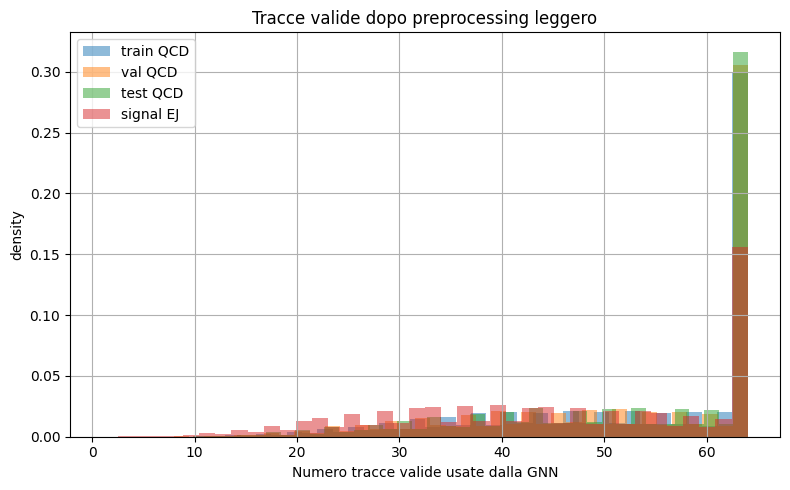

In [9]:
idx_deta = find_feature_index(track_feature_names, ["deta", "delta_eta"])
idx_dphi = find_feature_index(track_feature_names, ["dphi", "delta_phi"])

if idx_deta is not None and idx_dphi is not None:
    KNN_COORD_IDX = [idx_deta, idx_dphi]
else:
    KNN_COORD_IDX = [0, 1] if n_track_features >= 2 else [0, 0]

print("Coordinate kNN:", KNN_COORD_IDX, [track_feature_names[i] for i in KNN_COORD_IDX])

plt.figure(figsize=(8, 5))
plt.hist(mask_train.sum(axis=1), bins=40, density=True, alpha=0.5, label="train QCD")
plt.hist(mask_val.sum(axis=1), bins=40, density=True, alpha=0.5, label="val QCD")
plt.hist(mask_bkg_test.sum(axis=1), bins=40, density=True, alpha=0.5, label="test QCD")
plt.hist(mask_sig.sum(axis=1), bins=40, density=True, alpha=0.5, label="signal EJ")
plt.xlabel("Numero tracce valide usate dalla GNN")
plt.ylabel("density")
plt.title("Tracce valide dopo preprocessing leggero")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "valid_tracks_after_light_preprocessing.png", dpi=200)
plt.show()

class JetTrackDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(np.asarray(X_jets, dtype=np.float32))
        self.X_tracks = torch.from_numpy(np.asarray(X_tracks, dtype=np.float32))
        self.mask = torch.from_numpy(np.asarray(mask)).bool()

    def __len__(self):
        return self.X_tracks.shape[0]

    def __getitem__(self, idx):
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]

def make_loader(Xj, Xt, M, batch_size, shuffle=False):
    return DataLoader(
        JetTrackDataset(Xj, Xt, M),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

## 10. Loss e metriche comuni

In [10]:
def masked_track_mse(track_reco, x_tracks, mask, reduction="mean"):
    err = (track_reco - x_tracks) ** 2
    err = err * mask.unsqueeze(-1).float()
    denom = (mask.sum(dim=1).float() * x_tracks.shape[-1]).clamp_min(1.0)
    per_event = err.sum(dim=(1, 2)) / denom
    return per_event if reduction == "none" else per_event.mean()

def jet_mse(jet_reco, x_jets, reduction="mean"):
    if x_jets.shape[-1] == 0:
        per_event = torch.zeros(x_jets.shape[0], device=x_jets.device)
    else:
        per_event = torch.mean((jet_reco - x_jets) ** 2, dim=1)
    return per_event if reduction == "none" else per_event.mean()

def total_ae_loss(jet_reco, track_reco, x_jets, x_tracks, mask):
    jloss = jet_mse(jet_reco, x_jets)
    tloss = masked_track_mse(track_reco, x_tracks, mask)
    total = JET_LOSS_WEIGHT * jloss + TRACK_LOSS_WEIGHT * tloss
    return total, jloss, tloss

def orient_scores(bg, sig):
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])
    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)
    if auc_inv > auc:
        return -bg, -sig, auc_inv, True, auc, auc_inv
    return bg, sig, auc, False, auc, auc_inv

def evaluate_scores(bg, sig, model_name, score_name):
    bg_o, sig_o, best_auc, flipped, auc, auc_inv = orient_scores(bg, sig)
    y = np.concatenate([np.zeros_like(bg_o), np.ones_like(sig_o)])
    s = np.concatenate([bg_o, sig_o])
    fpr, tpr, thresholds = roc_curve(y, s)

    rows = []
    for mistag in [0.30, 0.10, 0.05, 0.01, 0.001]:
        threshold = np.quantile(bg_o, 1.0 - mistag)
        eff = np.mean(sig_o >= threshold)
        actual = np.mean(bg_o >= threshold)
        rows.append({
            "model": model_name,
            "score": score_name,
            "auc": best_auc,
            "raw_auc": auc,
            "auc_inverted": auc_inv,
            "flipped": flipped,
            "mistag_target": mistag,
            "actual_mistag": actual,
            "signal_efficiency": eff,
            "threshold": threshold,
        })

    return {
        "bg_oriented": bg_o,
        "sig_oriented": sig_o,
        "best_auc": best_auc,
        "auc": auc,
        "auc_inverted": auc_inv,
        "flipped": flipped,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "eff_table": pd.DataFrame(rows),
    }

def bg_vs_bg_auc(a, b, name_a, name_b):
    y = np.concatenate([np.zeros_like(a), np.ones_like(b)])
    s = np.concatenate([a, b])
    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)
    return {"comparison": f"{name_a} vs {name_b}", "auc": auc, "auc_inverted": auc_inv, "best_auc": max(auc, auc_inv)}

## 11. EdgeConv Autoencoder leggero

In [11]:
def masked_knn_indices(coords, mask, k=6):
    B, N, C = coords.shape
    dist = torch.cdist(coords, coords)

    invalid_j = ~mask.unsqueeze(1).expand(B, N, N)
    dist = dist.masked_fill(invalid_j, 1e9)

    eye = torch.eye(N, device=coords.device, dtype=torch.bool).unsqueeze(0)
    dist = dist.masked_fill(eye, 1e9)

    k_eff = min(k, max(N - 1, 1))
    return torch.topk(dist, k=k_eff, dim=-1, largest=False).indices

def gather_neighbors(h, idx):
    B, N, D = h.shape
    K = idx.shape[-1]
    idx_expanded = idx.unsqueeze(-1).expand(B, N, K, D)
    h_expanded = h.unsqueeze(1).expand(B, N, N, D)
    return torch.gather(h_expanded, dim=2, index=idx_expanded)

class EdgeConvBlock(nn.Module):
    def __init__(self, hidden_dim, dropout=0.05):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
        )

    def forward(self, h, coords, mask, k):
        idx = masked_knn_indices(coords, mask, k=k)
        neigh = gather_neighbors(h, idx)
        h_i = h.unsqueeze(2).expand_as(neigh)
        edge_feat = torch.cat([h_i, neigh - h_i], dim=-1)
        edge_h = self.edge_mlp(edge_feat)
        out = edge_h.max(dim=2).values + h
        return out * mask.unsqueeze(-1).float()

class LightEdgeConvAE(nn.Module):
    def __init__(self, n_track_features, n_jet_features, coord_idx, hidden_dim=64, latent_dim=16, n_blocks=2, k=6, dropout=0.05):
        super().__init__()
        self.coord_idx = coord_idx
        self.k = k
        self.n_jet_features = n_jet_features

        self.track_embed = nn.Sequential(
            nn.Linear(n_track_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
        )

        self.blocks = nn.ModuleList([EdgeConvBlock(hidden_dim, dropout=dropout) for _ in range(n_blocks)])

        self.jet_encoder = nn.Sequential(
            nn.Linear(n_jet_features, hidden_dim) if n_jet_features > 0 else nn.Linear(1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
        )

        self.to_latent = nn.Sequential(
            nn.Linear(3 * hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

        self.jet_decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, n_jet_features if n_jet_features > 0 else 1),
        )

        self.track_decoder = nn.Sequential(
            nn.Linear(hidden_dim + latent_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, n_track_features),
        )

    def forward(self, x_jets, x_tracks, mask):
        coords = x_tracks[:, :, self.coord_idx]
        h = self.track_embed(x_tracks) * mask.unsqueeze(-1).float()

        for block in self.blocks:
            h = block(h, coords, mask, self.k)

        mask_f = mask.unsqueeze(-1).float()
        counts = mask_f.sum(dim=1).clamp_min(1.0)
        mean_pool = (h * mask_f).sum(dim=1) / counts

        h_for_max = h.masked_fill(~mask.unsqueeze(-1), -1e9)
        max_pool = h_for_max.max(dim=1).values
        max_pool = torch.where(torch.isfinite(max_pool), max_pool, torch.zeros_like(max_pool))

        if self.n_jet_features > 0:
            jet_h = self.jet_encoder(x_jets)
        else:
            dummy = torch.zeros((x_tracks.shape[0], 1), device=x_tracks.device)
            jet_h = self.jet_encoder(dummy)

        z = self.to_latent(torch.cat([mean_pool, max_pool, jet_h], dim=1))

        jet_reco = self.jet_decoder(z)
        if self.n_jet_features == 0:
            jet_reco = jet_reco[:, :0]

        z_nodes = z.unsqueeze(1).expand(-1, x_tracks.shape[1], -1)
        track_reco = self.track_decoder(torch.cat([h, z_nodes], dim=-1))
        track_reco = track_reco * mask.unsqueeze(-1).float()

        return jet_reco, track_reco, z

## 12. Attention/Transformer Graph Autoencoder leggero

In [12]:
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, h, mask):
        logits = self.score(h).squeeze(-1)
        logits = logits.masked_fill(~mask, -1e9)
        w = torch.softmax(logits, dim=1)
        pooled = torch.sum(h * w.unsqueeze(-1), dim=1)
        return pooled, w

class LightAttentionGNN_AE(nn.Module):
    def __init__(self, n_track_features, n_jet_features, hidden_dim=64, latent_dim=16, n_layers=2, n_heads=4, dropout=0.05):
        super().__init__()
        self.n_jet_features = n_jet_features

        self.track_embed = nn.Sequential(
            nn.Linear(n_track_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            dim_feedforward=2 * hidden_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.pool = AttentionPooling(hidden_dim)

        self.jet_encoder = nn.Sequential(
            nn.Linear(n_jet_features, hidden_dim) if n_jet_features > 0 else nn.Linear(1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
        )

        self.to_latent = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

        self.jet_decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, n_jet_features if n_jet_features > 0 else 1),
        )

        self.track_decoder = nn.Sequential(
            nn.Linear(hidden_dim + latent_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, n_track_features),
        )

    def forward(self, x_jets, x_tracks, mask):
        h = self.track_embed(x_tracks)
        h = self.encoder(h, src_key_padding_mask=~mask)
        h = h * mask.unsqueeze(-1).float()

        pooled, attn_weights = self.pool(h, mask)

        if self.n_jet_features > 0:
            jet_h = self.jet_encoder(x_jets)
        else:
            dummy = torch.zeros((x_tracks.shape[0], 1), device=x_tracks.device)
            jet_h = self.jet_encoder(dummy)

        z = self.to_latent(torch.cat([pooled, jet_h], dim=1))

        jet_reco = self.jet_decoder(z)
        if self.n_jet_features == 0:
            jet_reco = jet_reco[:, :0]

        z_nodes = z.unsqueeze(1).expand(-1, x_tracks.shape[1], -1)
        track_reco = self.track_decoder(torch.cat([h, z_nodes], dim=-1))
        track_reco = track_reco * mask.unsqueeze(-1).float()

        return jet_reco, track_reco, z

## 13. Training e scoring

In [13]:
def evaluate_loss(model, loader):
    model.eval()
    total = total_j = total_t = 0.0
    n = 0
    with torch.no_grad():
        for xj, xt, m in loader:
            xj = xj.to(device, non_blocking=True)
            xt = xt.to(device, non_blocking=True)
            m = m.to(device, non_blocking=True)

            jr, tr, z = model(xj, xt, m)
            loss, jloss, tloss = total_ae_loss(jr, tr, xj, xt, m)

            bs = len(xj)
            total += loss.item() * bs
            total_j += jloss.item() * bs
            total_t += tloss.item() * bs
            n += bs

    return total / max(n, 1), total_j / max(n, 1), total_t / max(n, 1)

def train_model(model, model_name, batch_size):
    train_loader = make_loader(X_jets_train, X_tracks_train, mask_train, batch_size=batch_size, shuffle=True)
    val_loader = make_loader(X_jets_val, X_tracks_val, mask_val, batch_size=batch_size, shuffle=False)

    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)

    best_val = np.inf
    best_state = None
    best_epoch = -1
    no_improve = 0
    history = []

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        total = total_j = total_t = 0.0
        n = 0

        for xj, xt, m in train_loader:
            xj = xj.to(device, non_blocking=True)
            xt = xt.to(device, non_blocking=True)
            m = m.to(device, non_blocking=True)

            optimizer.zero_grad()
            jr, tr, z = model(xj, xt, m)
            loss, jloss, tloss = total_ae_loss(jr, tr, xj, xt, m)

            if not torch.isfinite(loss):
                raise RuntimeError(f"{model_name}: loss non finita")

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            bs = len(xj)
            total += loss.item() * bs
            total_j += jloss.item() * bs
            total_t += tloss.item() * bs
            n += bs

        train_loss = total / max(n, 1)
        train_j = total_j / max(n, 1)
        train_t = total_t / max(n, 1)

        val_loss, val_j, val_t = evaluate_loss(model, val_loader)
        scheduler.step(val_loss)
        lr_now = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_jet_loss": train_j,
            "train_track_loss": train_t,
            "val_loss": val_loss,
            "val_jet_loss": val_j,
            "val_track_loss": val_t,
            "lr": lr_now,
        })

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        print(
            f"{model_name} | epoch {epoch:03d}/{N_EPOCHS} | "
            f"train={train_loss:.5f} val={val_loss:.5f} "
            f"(jet={val_j:.5f}, track={val_t:.5f}) | "
            f"best={best_val:.5f}@{best_epoch} | lr={lr_now:.2e}"
        )

        if no_improve >= PATIENCE:
            print(f"{model_name}: early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    df_history = pd.DataFrame(history)
    df_history.to_csv(OUTPUT_DIR / f"{model_name}_history.csv", index=False)

    return model, df_history, {"best_val": best_val, "best_epoch": best_epoch}

@torch.no_grad()
def compute_outputs(model, Xj, Xt, M, batch_size):
    loader = make_loader(Xj, Xt, M, batch_size=batch_size, shuffle=False)
    model.eval()

    score_total = []
    score_jet = []
    score_track = []
    latents = []
    jet_recos = []
    track_recos = []

    for xj, xt, m in loader:
        xj = xj.to(device, non_blocking=True)
        xt = xt.to(device, non_blocking=True)
        m = m.to(device, non_blocking=True)

        jr, tr, z = model(xj, xt, m)

        sj = jet_mse(jr, xj, reduction="none")
        st = masked_track_mse(tr, xt, m, reduction="none")
        s = JET_LOSS_WEIGHT * sj + TRACK_LOSS_WEIGHT * st

        score_total.append(s.cpu().numpy())
        score_jet.append(sj.cpu().numpy())
        score_track.append(st.cpu().numpy())
        latents.append(z.cpu().numpy())
        jet_recos.append(jr.cpu().numpy())
        track_recos.append(tr.cpu().numpy())

    return {
        "score_total": np.concatenate(score_total),
        "score_jet": np.concatenate(score_jet),
        "score_track": np.concatenate(score_track),
        "latent": np.concatenate(latents, axis=0),
        "jet_reco": np.concatenate(jet_recos, axis=0),
        "track_reco": np.concatenate(track_recos, axis=0),
    }

def run_full_evaluation(model, model_name, batch_size):
    out_train = compute_outputs(model, X_jets_train, X_tracks_train, mask_train, batch_size)
    out_val = compute_outputs(model, X_jets_val, X_tracks_val, mask_val, batch_size)
    out_bkg = compute_outputs(model, X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test, batch_size)
    out_sig = compute_outputs(model, X_jets_sig, X_tracks_sig, mask_sig, batch_size)

    evals = {}
    rows = []

    for score_name in ["score_total", "score_jet", "score_track"]:
        ev = evaluate_scores(out_bkg[score_name], out_sig[score_name], model_name=model_name, score_name=score_name)
        evals[score_name] = ev
        rows.append({
            "model": model_name,
            "score": score_name,
            "auc": ev["best_auc"],
            "auc_inverted": ev["auc_inverted"],
            "flipped": ev["flipped"],
        })

    df_scores = pd.DataFrame(rows).sort_values("auc", ascending=False).reset_index(drop=True)
    best_score = df_scores.iloc[0]["score"]
    best_eval = evals[best_score]

    bg_checks = pd.DataFrame([
        bg_vs_bg_auc(out_train[best_score], out_val[best_score], "train QCD", "val QCD"),
        bg_vs_bg_auc(out_train[best_score], out_bkg[best_score], "train QCD", "test QCD"),
        bg_vs_bg_auc(out_val[best_score], out_bkg[best_score], "val QCD", "test QCD"),
    ])

    return {
        "out_train": out_train,
        "out_val": out_val,
        "out_bkg": out_bkg,
        "out_sig": out_sig,
        "evals": evals,
        "df_scores": df_scores,
        "best_score": best_score,
        "best_eval": best_eval,
        "background_checks": bg_checks,
    }

## 14. Esecuzione EdgeConv

In [14]:
results = {}

if RUN_EDGECONV:
    edge_model = LightEdgeConvAE(
        n_track_features=n_track_features,
        n_jet_features=n_jet_features,
        coord_idx=KNN_COORD_IDX,
        hidden_dim=EDGE_HIDDEN_DIM,
        latent_dim=EDGE_LATENT_DIM,
        n_blocks=EDGE_N_BLOCKS,
        k=EDGE_K,
        dropout=0.05,
    )

    print(edge_model)
    print("Parameters:", sum(p.numel() for p in edge_model.parameters() if p.requires_grad))

    edge_model, edge_history, edge_train_info = train_model(
        edge_model,
        model_name="edgeconv_light",
        batch_size=BATCH_SIZE_EDGECONV,
    )

    edge_eval = run_full_evaluation(edge_model, model_name="EdgeConv light", batch_size=BATCH_SIZE_EDGECONV)

    results["edgeconv_light"] = {
        "model": edge_model,
        "history": edge_history,
        "train_info": edge_train_info,
        "eval": edge_eval,
    }

    display(edge_eval["df_scores"])
    display(edge_eval["best_eval"]["eff_table"])
    display(edge_eval["background_checks"])
else:
    print("EdgeConv skipped.")

LightEdgeConvAE(
  (track_embed): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): SiLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (5): SiLU()
  )
  (blocks): ModuleList(
    (0-1): 2 x EdgeConvBlock(
      (edge_mlp): Sequential(
        (0): Linear(in_features=128, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): SiLU()
        (3): Dropout(p=0.05, inplace=False)
        (4): Linear(in_features=64, out_features=64, bias=True)
        (5): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (6): SiLU()
      )
    )
  )
  (jet_encoder): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): SiLU()
  )
  (to_latent): Sequential(
    (0): Linear(in_features=1

,model,score,auc,auc_inverted,flipped
0,EdgeConv light,score_total,0.676674,0.323326,False
1,EdgeConv light,score_jet,0.665396,0.334604,False
2,EdgeConv light,score_track,0.642733,0.357267,False


,model,score,auc,raw_auc,auc_inverted,flipped,mistag_target,actual_mistag,signal_efficiency,threshold
0,EdgeConv light,score_total,0.676674,0.676674,0.323326,False,0.300,0.300,0.542600,0.000092
1,EdgeConv light,score_total,0.676674,0.676674,0.323326,False,0.100,0.100,0.233875,0.000156
2,EdgeConv light,score_total,0.676674,0.676674,0.323326,False,0.050,0.050,0.130925,0.000215
3,EdgeConv light,score_total,0.676674,0.676674,0.323326,False,0.010,0.010,0.015375,0.000506
4,EdgeConv light,score_total,0.676674,0.676674,0.323326,False,0.001,0.001,0.000600,0.002082


,comparison,auc,auc_inverted,best_auc
0,train QCD vs val QCD,0.499544,0.500456,0.500456
1,train QCD vs test QCD,0.496545,0.503455,0.503455
2,val QCD vs test QCD,0.496962,0.503038,0.503038


## 15. Esecuzione Attention GNN

In [15]:
if RUN_ATTENTION_GNN:
    attn_model = LightAttentionGNN_AE(
        n_track_features=n_track_features,
        n_jet_features=n_jet_features,
        hidden_dim=ATTN_EMBED_DIM,
        latent_dim=ATTN_LATENT_DIM,
        n_layers=ATTN_N_LAYERS,
        n_heads=ATTN_N_HEADS,
        dropout=ATTN_DROPOUT,
    )

    print(attn_model)
    print("Parameters:", sum(p.numel() for p in attn_model.parameters() if p.requires_grad))

    attn_model, attn_history, attn_train_info = train_model(
        attn_model,
        model_name="attention_gnn_light",
        batch_size=BATCH_SIZE_ATTENTION,
    )

    attn_eval = run_full_evaluation(attn_model, model_name="Attention GNN light", batch_size=BATCH_SIZE_ATTENTION)

    results["attention_gnn_light"] = {
        "model": attn_model,
        "history": attn_history,
        "train_info": attn_train_info,
        "eval": attn_eval,
    }

    display(attn_eval["df_scores"])
    display(attn_eval["best_eval"]["eff_table"])
    display(attn_eval["background_checks"])
else:
    print("Attention GNN skipped.")

LightAttentionGNN_AE(
  (track_embed): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): SiLU()
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.05, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.05, inplace=False)
        (dropout2): Dropout(p=0.05, inplace=False)
      )
    )
  )
  (pool): AttentionPooling(
    (score): Sequential(
      (0): Linear(in_features=64, out_features=64, b

,model,score,auc,auc_inverted,flipped
0,Attention GNN light,score_track,0.683838,0.316162,False
1,Attention GNN light,score_total,0.637923,0.362077,False
2,Attention GNN light,score_jet,0.595118,0.404882,False


,model,score,auc,raw_auc,auc_inverted,flipped,mistag_target,actual_mistag,signal_efficiency,threshold
0,Attention GNN light,score_track,0.683838,0.683838,0.316162,False,0.300,0.300,0.545225,0.000040
1,Attention GNN light,score_track,0.683838,0.683838,0.316162,False,0.100,0.100,0.195250,0.000056
2,Attention GNN light,score_track,0.683838,0.683838,0.316162,False,0.050,0.050,0.092175,0.000069
3,Attention GNN light,score_track,0.683838,0.683838,0.316162,False,0.010,0.010,0.012500,0.000121
4,Attention GNN light,score_track,0.683838,0.683838,0.316162,False,0.001,0.001,0.001150,0.000338


,comparison,auc,auc_inverted,best_auc
0,train QCD vs val QCD,0.500746,0.499254,0.500746
1,train QCD vs test QCD,0.503777,0.496223,0.503777
2,val QCD vs test QCD,0.503052,0.496948,0.503052


## 16. Confronto finale GNN leggere

In [16]:
summary_rows = []
roc_rows = []
background_rows = []

for key, pack in results.items():
    ev_pack = pack["eval"]
    best_score = ev_pack["best_score"]
    best_eval = ev_pack["best_eval"]

    row = {
        "model_key": key,
        "model": best_eval["eff_table"]["model"].iloc[0],
        "best_score": best_score,
        "auc": best_eval["best_auc"],
        "best_epoch": pack["train_info"]["best_epoch"],
        "best_val_loss": pack["train_info"]["best_val"],
    }

    for _, r in best_eval["eff_table"].iterrows():
        row[f"eff_at_{r['mistag_target']:g}_mistag"] = r["signal_efficiency"]

    summary_rows.append(row)

    for fpr, tpr in zip(best_eval["fpr"], best_eval["tpr"]):
        roc_rows.append({
            "model": row["model"],
            "score": best_score,
            "fpr": fpr,
            "tpr": tpr,
            "auc": best_eval["best_auc"],
        })

    bgc = ev_pack["background_checks"].copy()
    bgc["model"] = row["model"]
    bgc["score"] = best_score
    background_rows.append(bgc)

summary_df = pd.DataFrame(summary_rows).sort_values("auc", ascending=False).reset_index(drop=True)
roc_df = pd.DataFrame(roc_rows)
background_df = pd.concat(background_rows, ignore_index=True) if background_rows else pd.DataFrame()

display(summary_df)
display(background_df)

summary_df.to_csv(OUTPUT_DIR / "gnn_light_results.csv", index=False)
roc_df.to_csv(OUTPUT_DIR / "gnn_light_roc_curves.csv", index=False)
background_df.to_csv(OUTPUT_DIR / "gnn_light_background_checks.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "gnn_light_results.csv")
print(OUTPUT_DIR / "gnn_light_roc_curves.csv")
print(OUTPUT_DIR / "gnn_light_background_checks.csv")

,model_key,model,best_score,auc,best_epoch,best_val_loss,eff_at_0.3_mistag,eff_at_0.1_mistag,eff_at_0.05_mistag,eff_at_0.01_mistag,eff_at_0.001_mistag
0,attention_gnn_light,Attention GNN light,score_track,0.683838,69,0.000085,0.545225,0.195250,0.092175,0.012500,0.00115
1,edgeconv_light,EdgeConv light,score_total,0.676674,70,0.000096,0.542600,0.233875,0.130925,0.015375,0.00060


,comparison,auc,auc_inverted,best_auc,model,score
0,train QCD vs val QCD,0.499544,0.500456,0.500456,EdgeConv light,score_total
1,train QCD vs test QCD,0.496545,0.503455,0.503455,EdgeConv light,score_total
2,val QCD vs test QCD,0.496962,0.503038,0.503038,EdgeConv light,score_total
3,train QCD vs val QCD,0.500746,0.499254,0.500746,Attention GNN light,score_track
4,train QCD vs test QCD,0.503777,0.496223,0.503777,Attention GNN light,score_track
5,val QCD vs test QCD,0.503052,0.496948,0.503052,Attention GNN light,score_track


Saved:
..\outputs\gnn_light\gnn_light_results.csv
..\outputs\gnn_light\gnn_light_roc_curves.csv
..\outputs\gnn_light\gnn_light_background_checks.csv


## 17. Plot finali

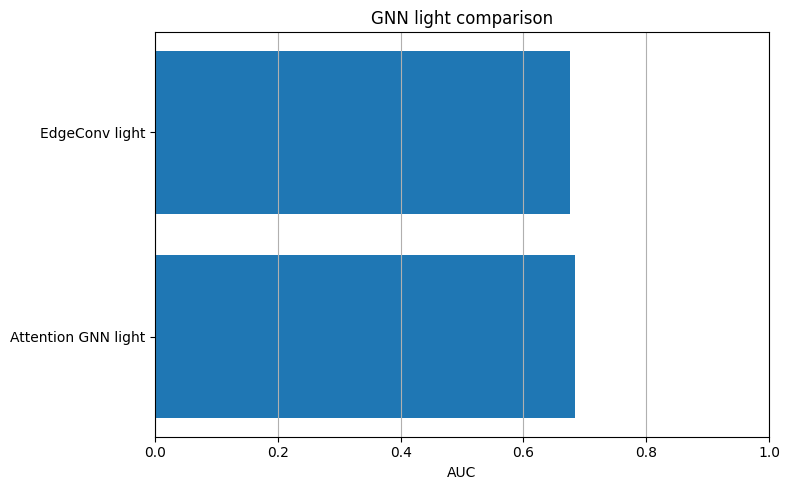

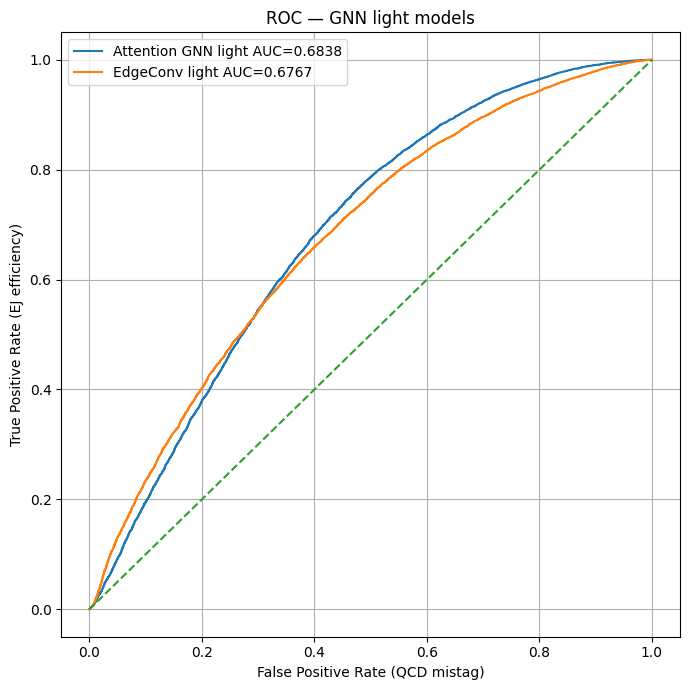

In [17]:
if len(summary_df):
    plt.figure(figsize=(8, 5))
    plt.barh(summary_df["model"], summary_df["auc"])
    plt.xlabel("AUC")
    plt.title("GNN light comparison")
    plt.xlim(0, 1)
    plt.grid(True, axis="x")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "gnn_light_auc_comparison.png", dpi=200)
    plt.show()

if len(roc_df):
    plt.figure(figsize=(7, 7))
    for model, g in roc_df.groupby("model"):
        g = g.sort_values("fpr")
        auc_val = g["auc"].iloc[0]
        plt.plot(g["fpr"], g["tpr"], label=f"{model} AUC={auc_val:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate (QCD mistag)")
    plt.ylabel("True Positive Rate (EJ efficiency)")
    plt.title("ROC — GNN light models")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "gnn_light_roc.png", dpi=200)
    plt.show()

## 18. Per-feature reconstruction error

,model,feature_type,feature,mse_bkg,mse_sig,ratio_sig_over_bkg
39,Attention GNN light,jet,Tau2_clusterSoftDrop,0.000210,0.000471,2.239107
32,Attention GNN light,jet,eta,0.000180,0.000390,2.158954
41,Attention GNN light,jet,Tau4_clusterSoftDrop,0.000140,0.000287,2.049525
40,Attention GNN light,jet,Tau3_clusterSoftDrop,0.000237,0.000374,1.578066
38,Attention GNN light,jet,Tau1_clusterSoftDrop,0.000389,0.000581,1.492645
50,Attention GNN light,track,dphi,0.000041,0.000057,1.411364
54,Attention GNN light,track,IP3D_signed_d0_significance,0.000059,0.000082,1.382780
47,Attention GNN light,track,d0_log1p,0.000035,0.000046,1.319183
46,Attention GNN light,track,pt_log1p,0.000041,0.000054,1.314230
48,Attention GNN light,track,z0SinTheta,0.000058,0.000073,1.249832


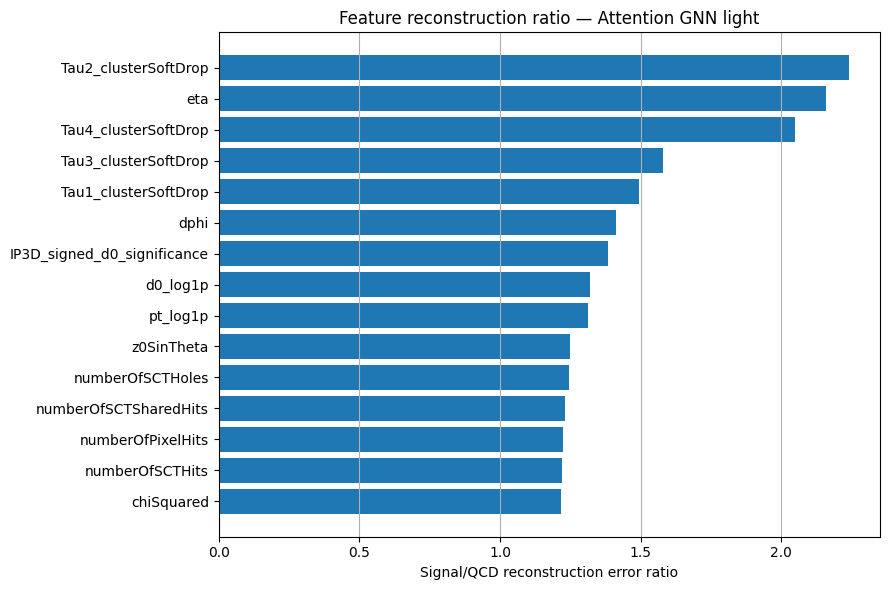

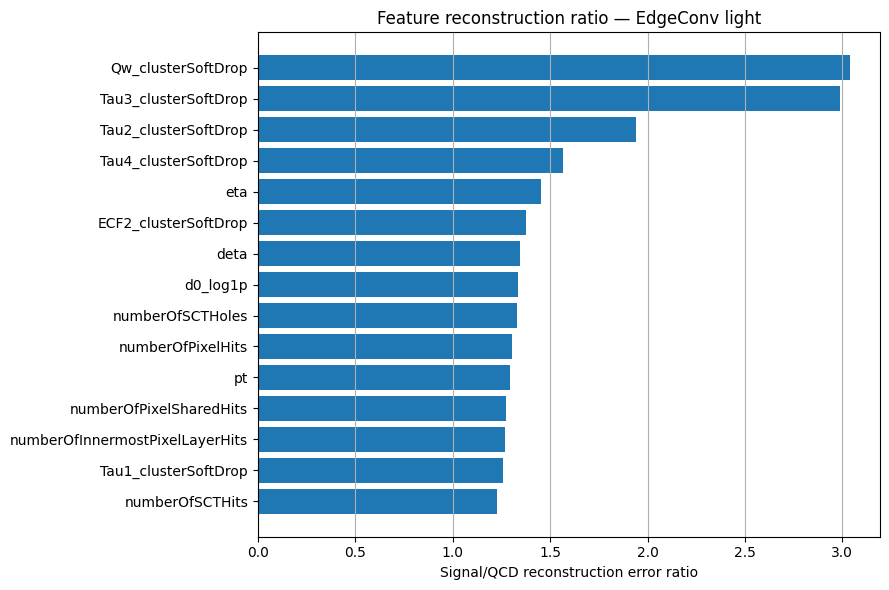

Saved: ..\outputs\gnn_light\gnn_light_feature_reconstruction_errors.csv


In [18]:
def jet_feature_errors(X_jets, jet_reco):
    if X_jets.shape[1] == 0:
        return np.array([])
    return np.mean((jet_reco - X_jets) ** 2, axis=0)

def track_feature_errors(X_tracks, track_reco, mask):
    err = (track_reco - X_tracks) ** 2
    out = []
    for j in range(X_tracks.shape[-1]):
        vals = err[:, :, j][mask]
        out.append(float(np.mean(vals)) if vals.size else np.nan)
    return np.array(out)

if DO_FEATURE_RECONSTRUCTION_ERRORS and len(results):
    all_feature_error_rows = []

    for key, pack in results.items():
        model_name = pack["eval"]["best_eval"]["eff_table"]["model"].iloc[0]
        out_bkg = pack["eval"]["out_bkg"]
        out_sig = pack["eval"]["out_sig"]

        jet_bkg = jet_feature_errors(X_jets_bkg_test, out_bkg["jet_reco"])
        jet_sig = jet_feature_errors(X_jets_sig, out_sig["jet_reco"])

        track_bkg = track_feature_errors(X_tracks_bkg_test, out_bkg["track_reco"], mask_bkg_test)
        track_sig = track_feature_errors(X_tracks_sig, out_sig["track_reco"], mask_sig)

        for i, feat in enumerate(jet_feature_names):
            all_feature_error_rows.append({
                "model": model_name,
                "feature_type": "jet",
                "feature": feat,
                "mse_bkg": jet_bkg[i],
                "mse_sig": jet_sig[i],
                "ratio_sig_over_bkg": jet_sig[i] / max(jet_bkg[i], 1e-12),
            })

        for i, feat in enumerate(track_feature_names):
            all_feature_error_rows.append({
                "model": model_name,
                "feature_type": "track",
                "feature": feat,
                "mse_bkg": track_bkg[i],
                "mse_sig": track_sig[i],
                "ratio_sig_over_bkg": track_sig[i] / max(track_bkg[i], 1e-12),
            })

    feature_errors_df = pd.DataFrame(all_feature_error_rows)
    feature_errors_df = feature_errors_df.sort_values(["model", "ratio_sig_over_bkg"], ascending=[True, False])
    feature_errors_df.to_csv(OUTPUT_DIR / "gnn_light_feature_reconstruction_errors.csv", index=False)

    display(feature_errors_df.groupby("model").head(15))

    for model_name, g in feature_errors_df.groupby("model"):
        top = g.sort_values("ratio_sig_over_bkg", ascending=False).head(15).iloc[::-1]
        plt.figure(figsize=(9, 6))
        plt.barh(top["feature"], top["ratio_sig_over_bkg"])
        plt.xlabel("Signal/QCD reconstruction error ratio")
        plt.title(f"Feature reconstruction ratio — {model_name}")
        plt.grid(True, axis="x")
        plt.tight_layout()
        safe_name = model_name.lower().replace(" ", "_")
        plt.savefig(PLOTS_DIR / f"{safe_name}_feature_reco_ratio.png", dpi=200)
        plt.show()

    print("Saved:", OUTPUT_DIR / "gnn_light_feature_reconstruction_errors.csv")
else:
    print("Per-feature reconstruction error skipped.")

## 19. Diagnostica supervisionata sul latent

In [19]:
if DO_LATENT_LOGISTIC_DIAGNOSTIC and len(results):
    latent_rows = []

    for key, pack in results.items():
        model_name = pack["eval"]["best_eval"]["eff_table"]["model"].iloc[0]
        Z_bkg = pack["eval"]["out_bkg"]["latent"]
        Z_sig = pack["eval"]["out_sig"]["latent"]

        X = np.concatenate([Z_bkg, Z_sig], axis=0)
        y = np.concatenate([np.zeros(len(Z_bkg)), np.ones(len(Z_sig))])

        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.3, random_state=SEED, stratify=y
        )

        clf = LogisticRegression(max_iter=3000)
        clf.fit(X_tr, y_tr)
        proba = clf.predict_proba(X_te)[:, 1]
        auc_lat = roc_auc_score(y_te, proba)

        latent_rows.append({
            "model": model_name,
            "latent_logistic_auc": auc_lat,
            "note": "diagnostica supervisionata, non anomaly detection",
        })

    latent_diag_df = pd.DataFrame(latent_rows)
    latent_diag_df.to_csv(OUTPUT_DIR / "gnn_light_latent_logistic_diagnostic.csv", index=False)
    display(latent_diag_df)
else:
    print("Latent logistic diagnostic skipped.")

,model,latent_logistic_auc,note
0,EdgeConv light,0.933792,"diagnostica supervisionata, non anomaly detection"
1,Attention GNN light,0.940961,"diagnostica supervisionata, non anomaly detection"


## 20. Salvataggio model checkpoint e score

In [20]:
for key, pack in results.items():
    model = pack["model"]
    ev_pack = pack["eval"]
    model_name = ev_pack["best_eval"]["eff_table"]["model"].iloc[0]
    safe_name = key

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "model_key": key,
            "model_name": model_name,
            "track_feature_names": track_feature_names,
            "jet_feature_names": jet_feature_names,
            "config": {
                "MAX_TRACKS_GNN": MAX_TRACKS_GNN,
                "MAX_TRAIN": MAX_TRAIN,
                "MAX_EVAL": MAX_EVAL,
                "MAX_SIG": MAX_SIG,
                "TRACK_LOSS_WEIGHT": TRACK_LOSS_WEIGHT,
                "JET_LOSS_WEIGHT": JET_LOSS_WEIGHT,
                "best_score": ev_pack["best_score"],
                "best_auc": float(ev_pack["best_eval"]["best_auc"]),
                "best_epoch": int(pack["train_info"]["best_epoch"]),
            },
        },
        OUTPUT_DIR / f"{safe_name}_model.pt",
    )

    np.savez_compressed(
        OUTPUT_DIR / f"{safe_name}_scores.npz",
        scores_train_total=ev_pack["out_train"]["score_total"],
        scores_val_total=ev_pack["out_val"]["score_total"],
        scores_bkg_test_total=ev_pack["out_bkg"]["score_total"],
        scores_sig_total=ev_pack["out_sig"]["score_total"],
        scores_train_jet=ev_pack["out_train"]["score_jet"],
        scores_val_jet=ev_pack["out_val"]["score_jet"],
        scores_bkg_test_jet=ev_pack["out_bkg"]["score_jet"],
        scores_sig_jet=ev_pack["out_sig"]["score_jet"],
        scores_train_track=ev_pack["out_train"]["score_track"],
        scores_val_track=ev_pack["out_val"]["score_track"],
        scores_bkg_test_track=ev_pack["out_bkg"]["score_track"],
        scores_sig_track=ev_pack["out_sig"]["score_track"],
        Z_train=ev_pack["out_train"]["latent"],
        Z_val=ev_pack["out_val"]["latent"],
        Z_bkg_test=ev_pack["out_bkg"]["latent"],
        Z_sig=ev_pack["out_sig"]["latent"],
        fpr=ev_pack["best_eval"]["fpr"],
        tpr=ev_pack["best_eval"]["tpr"],
        thresholds=ev_pack["best_eval"]["thresholds"],
        best_auc=np.array(ev_pack["best_eval"]["best_auc"], dtype=np.float32),
        best_score_name=np.array(ev_pack["best_score"], dtype=object),
        track_feature_names=np.array(track_feature_names, dtype=object),
        jet_feature_names=np.array(jet_feature_names, dtype=object),
    )

print("Saved outputs in:", OUTPUT_DIR.resolve())
for p in sorted(OUTPUT_DIR.glob("*")):
    if p.is_file():
        print(" -", p.name)
print("Plots:")
for p in sorted(PLOTS_DIR.glob("*.png")):
    print(" - plots/" + p.name)

Saved outputs in: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\gnn_light
 - attention_gnn_light_history.csv
 - attention_gnn_light_model.pt
 - attention_gnn_light_scores.npz
 - edgeconv_light_history.csv
 - edgeconv_light_model.pt
 - edgeconv_light_scores.npz
 - gnn_light_background_checks.csv
 - gnn_light_feature_reconstruction_errors.csv
 - gnn_light_latent_logistic_diagnostic.csv
 - gnn_light_results.csv
 - gnn_light_roc_curves.csv
Plots:
 - plots/attention_gnn_light_feature_reco_ratio.png
 - plots/edgeconv_light_feature_reco_ratio.png
 - plots/gnn_light_auc_comparison.png
 - plots/gnn_light_roc.png
 - plots/valid_tracks_after_light_preprocessing.png


## 21. Commento finale per il report

Questa versione è volutamente più leggera della GNN completa.

La GNN completa usava fino a 200 tracce per jet e risultava troppo lenta per il computer locale.  
Qui ho mantenuto le stesse feature fisiche del preprocessing, ma ho ridotto il numero massimo di tracce a quelle più informative, ordinate per `pt_log1p`.

Nel report si può scrivere:

```text
A lightweight GNN study was implemented to make graph-based anomaly detection feasible on local hardware. 
The same preprocessed jet-level and track-level features were used, but only the leading tracks according to track pT were retained for graph construction.
Two architectures were compared: an EdgeConv autoencoder using kNN graphs in the (Δη, Δφ) plane, and an attention-based set/graph autoencoder.
Both models were trained only on QCD jets, and the anomaly score was defined as the masked reconstruction error on valid tracks, optionally combined with a small jet-level reconstruction term.
```

Se le GNN non superano Flow/Diffusion/AE, non è un problema: restano una componente esplorativa che soddisfa la parte "GNN on jet constituents" del progetto.